Here is the data regarding Melbourne housing market snapshot downloaded from Kaggle Website (https://www.kaggle.com/)
the data contains the following headers:

Suburb: Name of the suburb where the property is located.
Address: Full address of the property.
Rooms: Number of rooms in the property.
Type: Type of dwelling (e.g., house, townhouse, unit).
Price: Sale price of the property in Australian dollars.
Method: Method of sale (e.g., auction, private sale).
SellerG: Name of the real estate agent or agency.
Date: Date when the property was sold.
Distance: Distance of the property from Melbourne's Central Business District (CBD) in kilometers.
Postcode: Postal code of the property's location.
Bedroom: Number of bedrooms.
Bathroom: Number of bathrooms.
Car: Number of car parking spaces.
Landsize: Land size of the property in square meters.
BuildingArea: Building area of the property in square meters.
YearBuilt: Year the property was built.
CouncilArea: Governing council for the property's location.
Latitude: Latitude coordinate of the property.
Longitude: Longitude coordinate of the property.
Regionname: General region (e.g., Western Metropolitan, Southern Metropolitan) where the property is located.
Propertycount: Number of properties sold in the suburb.

1. use train-test split models- DistributionTreeRegressor and RandomForestRegressor- and find the optimum max_node_leaf solutions for predicting the prices.
2. after finding the best model, apply it to the whole data and plot the histograms of the predicted and real prices in the same figure.

In [23]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [24]:


# Path of the file to read
file = "C:/workFile\PowerBI\Data Resources\Melborn Housing\melb_data.xlsx"
data = pd.read_excel(file)

# Creating target and feature columns
y = data.Price
features = ['Rooms', 'Distance',	'Bedroom', 'Bathroom',
            'Landsize', 'BuildingArea', 'YearBuilt', 'Latitude', 'Longitude']
X = data[features]

# Split into validation and training data
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

In [25]:
def  calculated_MAE (node_depth, val_x, val_y, train_x, train_y):
    """calculated_MAE gets the data and returns the Mean Absolute Error"""
    # Split into validation and training data
    melborn_model = DecisionTreeRegressor(max_leaf_nodes = node_depth, random_state=1)
    #melborn_model = RandomForestRegressor(max_leaf_nodes = node_depth, random_state=1)
    melborn_model.fit(train_x, train_y)
    val_prediction = melborn_model.predict(val_x)
    val_mae = mean_absolute_error(val_prediction, val_y)
    return val_mae


In [26]:
possible_node_depth = [2, 4, 16, 32, 64, 128, 256, 512]
error = []
for depth in possible_node_depth:
    print(f"Validation MAE for maximum leaf depth, {depth}, is {calculated_MAE(depth, train_X, train_y, val_X, val_y)}\n")
    error.append(calculated_MAE(depth, train_X, train_y, val_X, val_y))
    
best_index = error.index(min(error))    
print(f"the optimum max leaf depth is {possible_node_depth[best_index]}")

Validation MAE for maximum leaf depth, 2, is 420407.67574354657

Validation MAE for maximum leaf depth, 4, is 379584.5979827173

Validation MAE for maximum leaf depth, 16, is 288776.2682458941

Validation MAE for maximum leaf depth, 32, is 264300.41051894595

Validation MAE for maximum leaf depth, 64, is 256267.66320921533

Validation MAE for maximum leaf depth, 128, is 248922.3244386737

Validation MAE for maximum leaf depth, 256, is 248704.0015075077

Validation MAE for maximum leaf depth, 512, is 253388.40715846047

the optimum max leaf depth is 256


In [27]:
best_model = DecisionTreeRegressor(max_leaf_nodes = possible_node_depth[best_index], random_state=1)
best_model.fit(X, y)
y_prediction = best_model.predict(X)
print(y_prediction)

[1197222.64516129 1197222.64516129 1260750.         ... 1194659.42028985
 2479444.44444444 1210546.51162791]


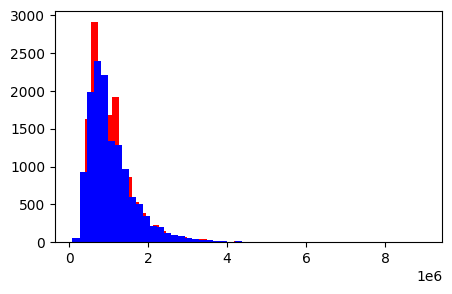

In [28]:
fig = plt.figure(figsize=(5, 3))
plt.hist(y_prediction, bins=50, color = 'red')
plt.hist(y, bins=50, color = 'blue')
plt.show()